### Clustering

#### 1. Data Loading

In [1]:
import pandas as pd

df = pd.read_csv("data/pca/cleaned_data.csv")
df.describe()

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,SP,BS,ROP,DRHO,LITHOLOGY
count,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000
mean,2426.485856,11.854190,2.762909,4.668206,4.693303,2.294450,71.477808,0.397697,5.823347,107.291108,48.998032,10.575671,22.657302,0.022613,61108.953984
std,721.828772,3.093467,11.856220,38.307630,55.783676,0.255689,32.498219,0.198608,5.856255,30.186918,138.137142,1.960491,17.986234,0.052292,14224.312834
min,761.041604,7.325138,0.005141,0.262247,0.264479,1.239131,6.024419,0.014492,1.074626,7.415132,-266.566284,8.500000,0.069603,-0.489363,30000.000000
25%,1863.174400,9.043562,0.841600,0.786579,0.686648,2.081967,54.144875,0.255004,3.288399,82.151833,38.700779,8.500000,8.395054,-0.011185,65000.000000
50%,2301.200000,12.342676,1.193334,1.280654,1.231505,2.312593,72.021515,0.361658,4.257130,99.381676,66.653862,12.250001,16.497211,0.007328,65000.000000
75%,3058.464000,13.364419,2.797484,3.580580,3.043633,2.532267,88.355316,0.500045,6.426693,134.931549,108.100883,12.250001,33.563400,0.044417,65000.000000
max,3907.120000,25.717396,779.958923,1988.616333,1999.877808,2.894546,1076.963867,0.999570,288.103638,205.208664,273.084320,17.500000,236.408310,0.308971,99000.000000


In [2]:
# Count values in df.LITHOLOGY
df.LITHOLOGY.value_counts()
# Drop rows with LITHOLOGY == 65000
df = df[df.LITHOLOGY != 65000]

#### 2. Outliers Removal and removing the label and categorical columns

In [3]:
cols = ['DEPTH_MD', 'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'NPHI', 'PEF', 'DTC', 'SP', 'ROP', 'DRHO']

def remove_outliers(df, cols):
    Q_lower = df[cols].quantile(0.15)
    Q_upper = df[cols].quantile(0.85)
    IQR = Q_upper - Q_lower
    df = df[~((df[cols] < (Q_lower - 1.5 * IQR)) | (df[cols] > (Q_upper + 1.5 * IQR))).any(axis=1)]
    return df

# Remove outliers for selected columns
df = remove_outliers(df, cols)
df.describe()

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,SP,BS,ROP,DRHO,LITHOLOGY
count,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000,10975.000000
mean,2706.935518,10.096484,2.626070,3.071435,2.684500,2.400122,44.813038,0.224508,5.148922,84.244723,109.228044,9.602711,16.289540,-0.004711,52965.302232
std,501.379457,2.330175,2.282020,2.686472,2.280408,0.176407,20.735933,0.091198,1.924761,16.591013,55.910593,1.742660,11.128836,0.031312,21500.307389
min,761.041604,7.453186,0.005141,0.298357,0.264479,1.612974,6.093219,0.029468,1.485867,46.385826,13.892606,8.500000,0.069603,-0.106550,30000.000000
25%,2316.788199,8.221805,0.955758,1.028763,0.848284,2.305664,30.767541,0.164974,3.715952,74.407204,70.089130,8.500000,8.456300,-0.028229,30000.000000
50%,2694.880000,9.018306,2.034022,2.292479,2.027410,2.411152,45.640335,0.211880,4.831584,82.464912,97.709526,8.500000,12.473228,-0.009691,65030.000000
75%,3097.304100,12.300086,3.403373,4.214041,3.770652,2.541067,58.366600,0.263148,6.141126,89.256668,121.591602,12.250001,21.743700,0.010161,70000.000000
max,3907.120000,20.118723,12.063251,16.061087,13.693203,2.873448,137.348282,0.645441,13.092713,166.211288,268.850494,17.500000,62.118404,0.121324,99000.000000


In [ ]:
df_nolabel = df.drop(columns=['LITHOLOGY'])
df_nolabel.to_csv("data/clustering/cleaned_data_nolabel.csv", index=False)

In [7]:
# Drop categorical columns
DFLabel = df["LITHOLOGY"]
DF = df.drop(columns=['WELL', 'GROUP', 'FORMATION', 'LITHOLOGY', 'BS'])

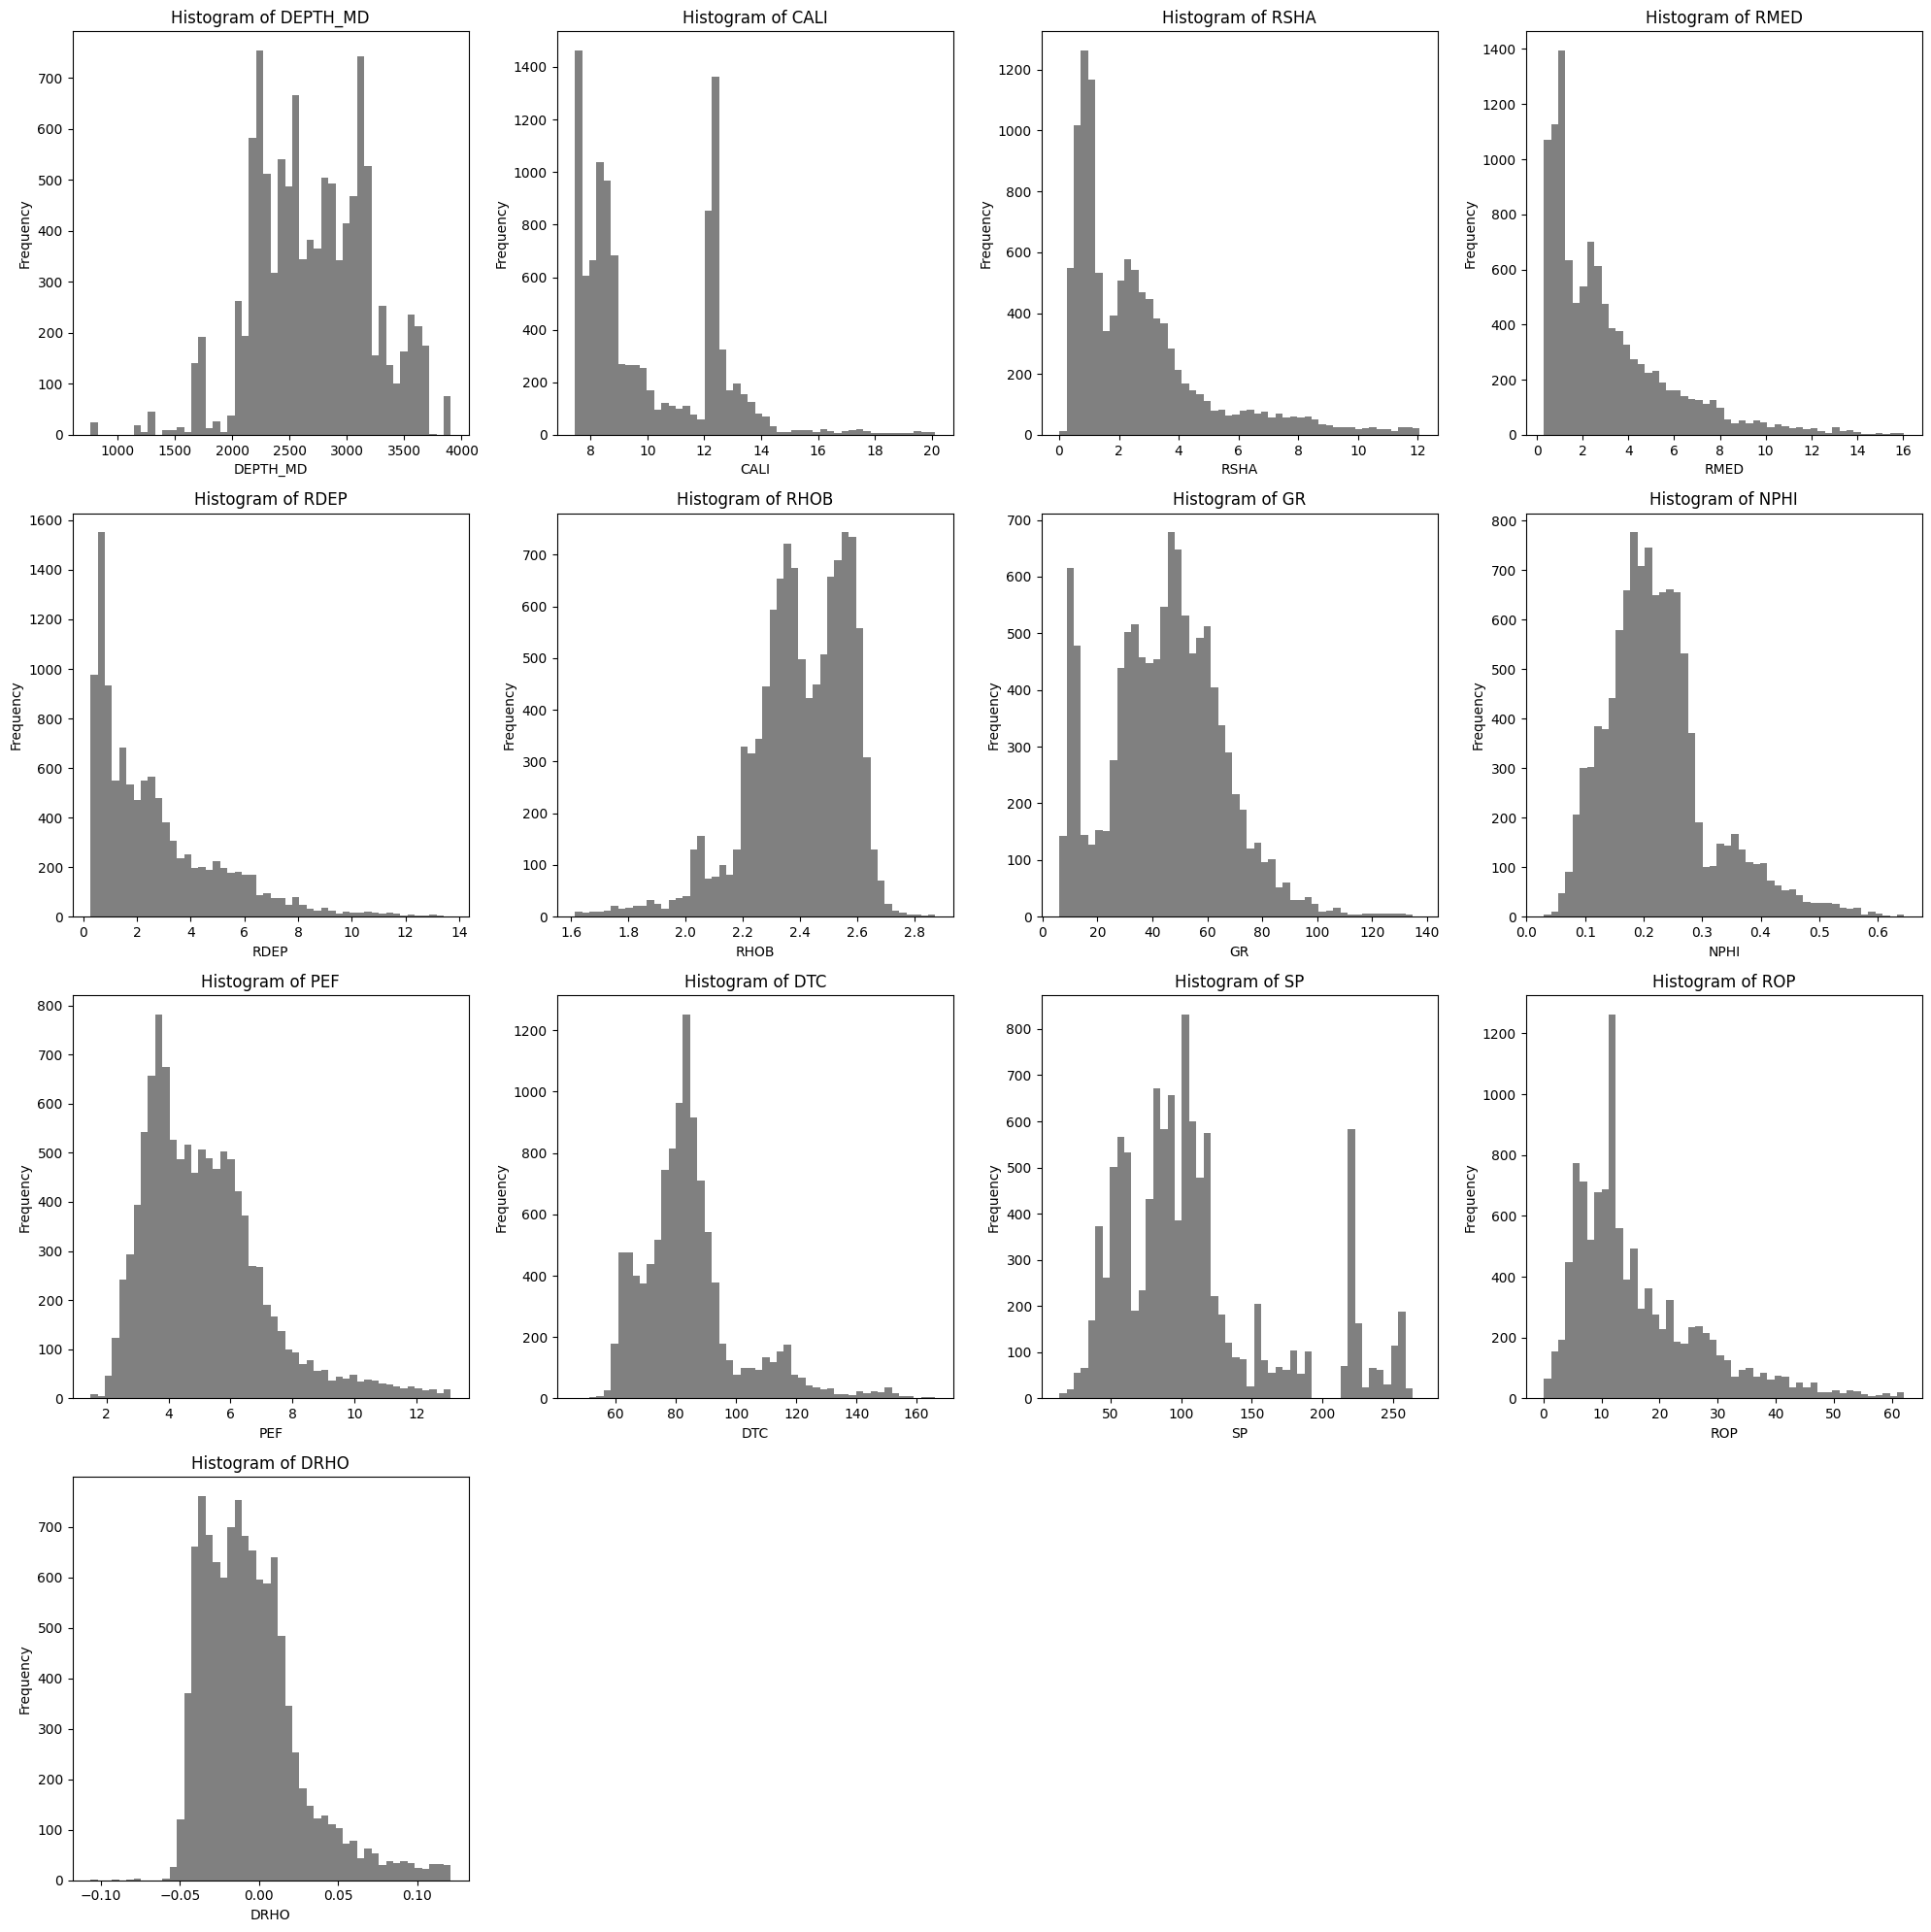

In [8]:
import matplotlib.pyplot as plt

# Histogram
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(DF.columns):
    axes[i].hist(DF[col], bins=50,color='grey', alpha=1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Histogram of {col}')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 3. Normalizing data

In [ ]:
# Normalize all columns using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
DF_scaled = scaler.fit_transform(DF)
DF_scaled = pd.DataFrame(DF_scaled, columns=DF.columns)
DF_scaled.describe()
DF_scaled.to_csv("data/clustering/normalized_data.csv", index=False)

#### 4.1 PCA with 2 components

In [ ]:
import plotly.express as px
from sklearn.decomposition import PCA

PCA_2components = PCA(n_components=2)

# Project the original data into the PCA space
Result = PCA_2components.fit_transform(DF_scaled)

# Create a DataFrame with the PCA results
pca_df = pd.DataFrame(Result, columns=['PC0', 'PC1'])

# Print the explained variance ratio
print("The explained variance ratio:", PCA_2components.explained_variance_ratio_)
# Print the explained variance
print("The eigenvalues:", PCA_2components.explained_variance_)

litho_code = {30000: "Sandstone", 65030: "SandstoneShale", 65000: "Shale", 80000: "Marl", 
            74000: "Dolomite", 70000: "Limestone", 70032: "Chalk", 88000: "Halite", 
            86000: "Anhydrite", 99000: "Tuff", 90000: "Coal", 93000: "Basement"}
# Map the lithology codes to their names
labels = DFLabel.values
DFLabel = DFLabel.map(litho_code)

# Plot the PCA results in 2D
fig = px.scatter(pca_df, x='PC0', y='PC1', color=DFLabel.astype(str), 
                 title='PCA of Lithology Data', labels={'color': 'Lithology'})
fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.update_layout(
    xaxis_title='Principal Component 1',
    yaxis_title='Principal Component 2',
    width=800,
    height=600
)
fig.show()

# 

The explained variance ratio: [0.35873589 0.16131548]
The eigenvalues: [4.66399153 2.09729229]


In [ ]:
# Total percentage of variance explained by the first two components
total_variance = PCA_2components.explained_variance_ratio_.sum() *100
print(f"Total percentage of variance explained by the first two components: {total_variance:.2f}%")

# Plot the PCA explained variance 
fig = px.bar(x=['PC1', 'PC2'], y=PCA_2components.explained_variance_ratio_, 
             title='PCA Explained Variance Ratio', 
             labels={'x': 'Principal Components', 'y': 'Explained Variance Ratio'})
fig.update_layout(
    xaxis_title='Principal Components',
    yaxis_title='Explained Variance Ratio',
    width=800,
    height=600
)
fig.show()

Total percentage of variance explained by the first two components: 52.01%


#### 4.2 PCA with 3 components

In [8]:
import plotly.express as px
from sklearn.decomposition import PCA

PCA_3components = PCA(n_components=3)

# Project the original data into the PCA space
Result = PCA_3components.fit_transform(DF_scaled)

# Create a DataFrame with the PCA results
pca_df = pd.DataFrame(Result, columns=['PC0', 'PC1', 'PC2'])

# Print the explained variance ratio
print("The explained variance ratio:", PCA_3components.explained_variance_ratio_)
# Print the explained variance
print("The eigenvalues:", PCA_3components.explained_variance_)

# Plot the PCA results in 3D
fig = px.scatter_3d(
    x=Result[:, 0],
    y=Result[:, 1],
    z=Result[:, 2],
    color=DFLabel.astype(str),
    labels={'x': 'PC0', 'y': 'PC1', 'z': 'PC2'},
    title='3D PCA',
    width=1000,
    height=600
)
fig.update_traces(marker=dict(size=3, opacity=0.5))

fig.show()


The explained variance ratio: [0.35873589 0.16131548 0.13217446]
The eigenvalues: [4.66399153 2.09729229 1.71842454]


In [37]:
# Total percentage of variance explained by the first two components
total_variance = PCA_3components.explained_variance_ratio_.sum() *100
print(f"Total percentage of variance explained by the first two components: {total_variance:.2f}%")

# Plot the PCA explained variance 
fig = px.bar(x=['PC1', 'PC2', 'PC3'], y=PCA_3components.explained_variance_ratio_, 
             title='PCA Explained Variance Ratio', 
             labels={'x': 'Principal Components', 'y': 'Explained Variance Ratio'})
fig.update_layout(
    xaxis_title='Principal Components',
    yaxis_title='Explained Variance Ratio',
    width=800,
    height=600
)
fig.show()

Total percentage of variance explained by the first two components: 65.22%


### I. K-Means Clustering

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Extract features and labels
X = pca_df[['PC0', 'PC1', 'PC2']]

# Determine best k values using Silhouette Score
sil_scores = {}

# Testing k from 2 to 9
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    sil_scores[k] = silhouette_score(X, cluster_labels)

# Choose the top 3 k values with highest silhouette scores
best_k_values = sorted(sil_scores, key=sil_scores.get, reverse=True)[:3]

In [ ]:
print("The best 3 k values are:", best_k_values)

[4, 3, 7]

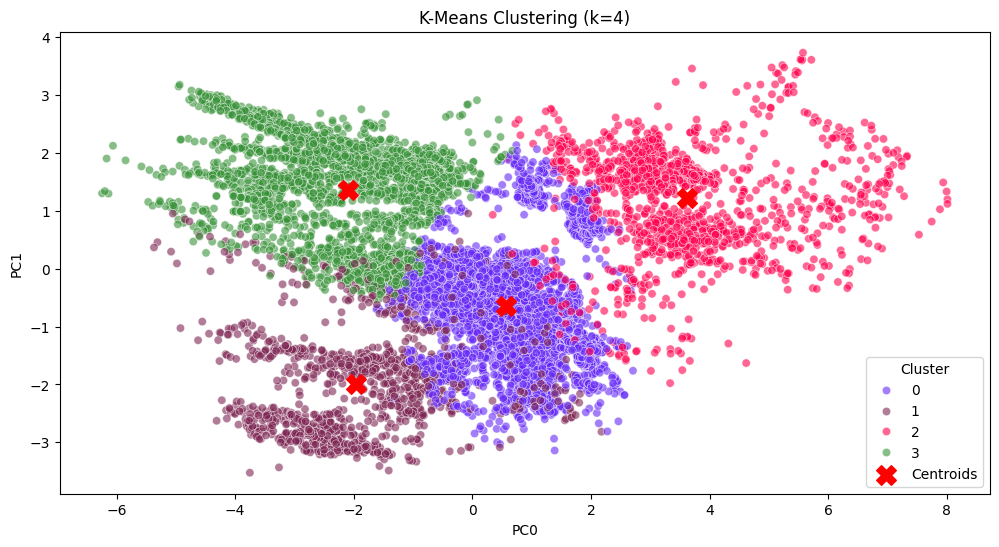

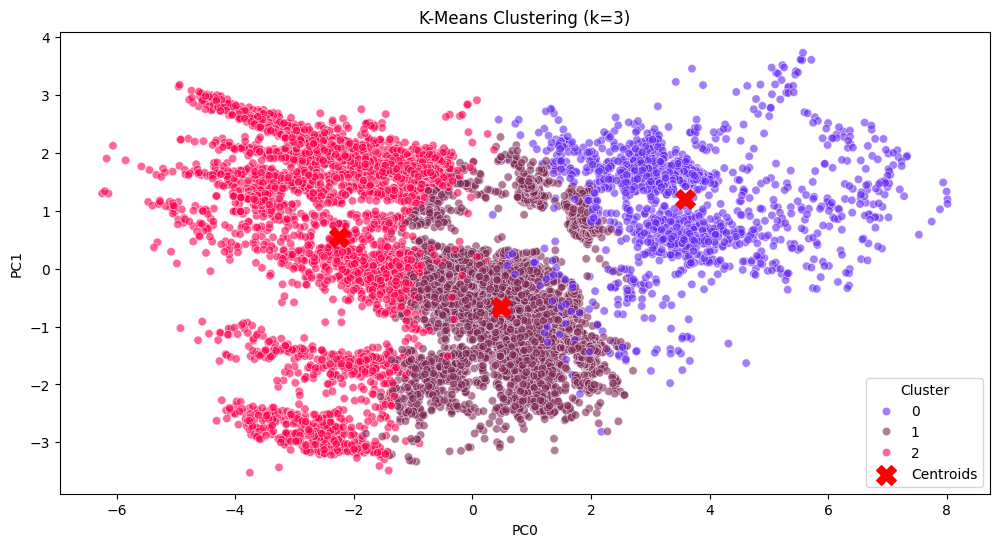

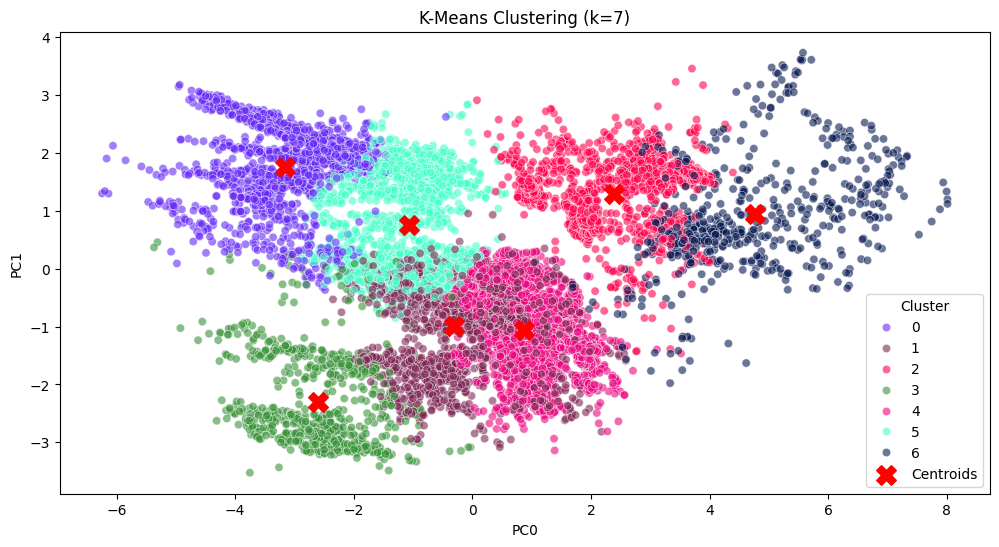

In [ ]:
# Plot data and centroids for each k
for k in best_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    pca_df[f'cluster_k{k}'] = kmeans.fit_predict(X)
    centroids = kmeans.cluster_centers_
    palette = ["#6528F7", "#7E2553", "#FF004D", "#379237", "#EA047E", "#45FFCA", "#071952"]
    palette = palette[:k]

    fig, ax = plt.subplots(figsize=(12, 6))

    # Scatter plot
    sns.scatterplot(x=pca_df['PC0'], y=pca_df['PC1'], hue=pca_df[f'cluster_k{k}'], palette=palette, alpha=0.6, ax=ax)
    
    # Scatter plot of cluster centroids
    ax.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')
    
    ax.set_title(f'K-Means Clustering (k={k})')
    ax.legend(title='Cluster', loc='lower right')
    plt.show()

### II. Hierarchical Clustering

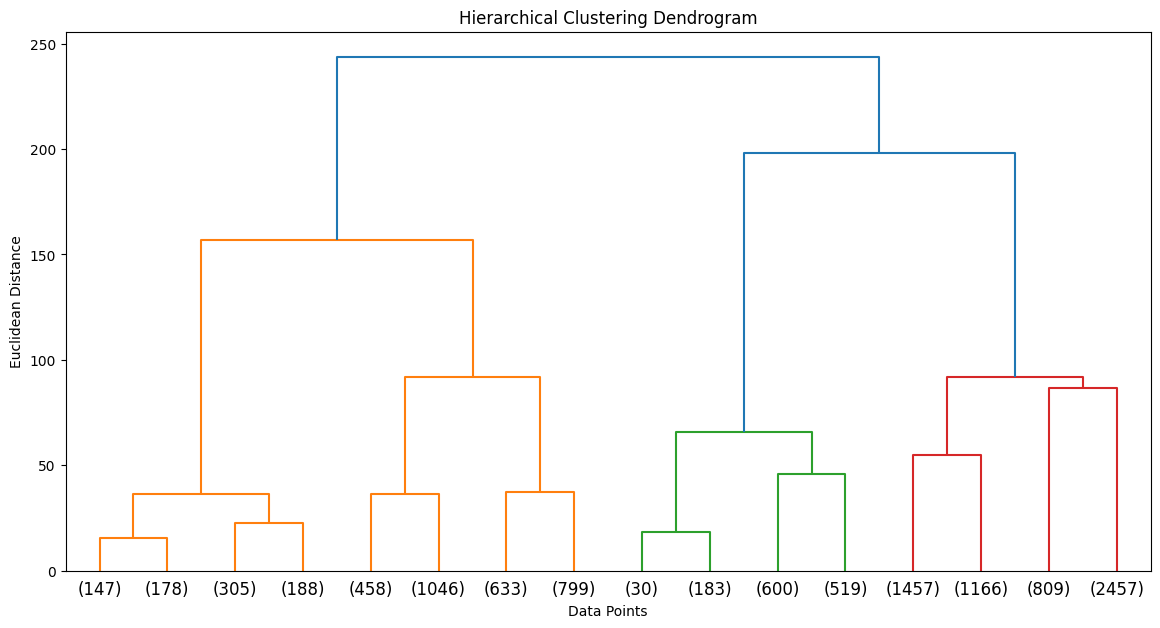

In [54]:
# Hierarchical Clustering and Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # Create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X)

plt.figure(figsize=(14, 7))
plot_dendrogram(model, truncate_mode="level", p=3)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()


### III. DBSCAN Clustering

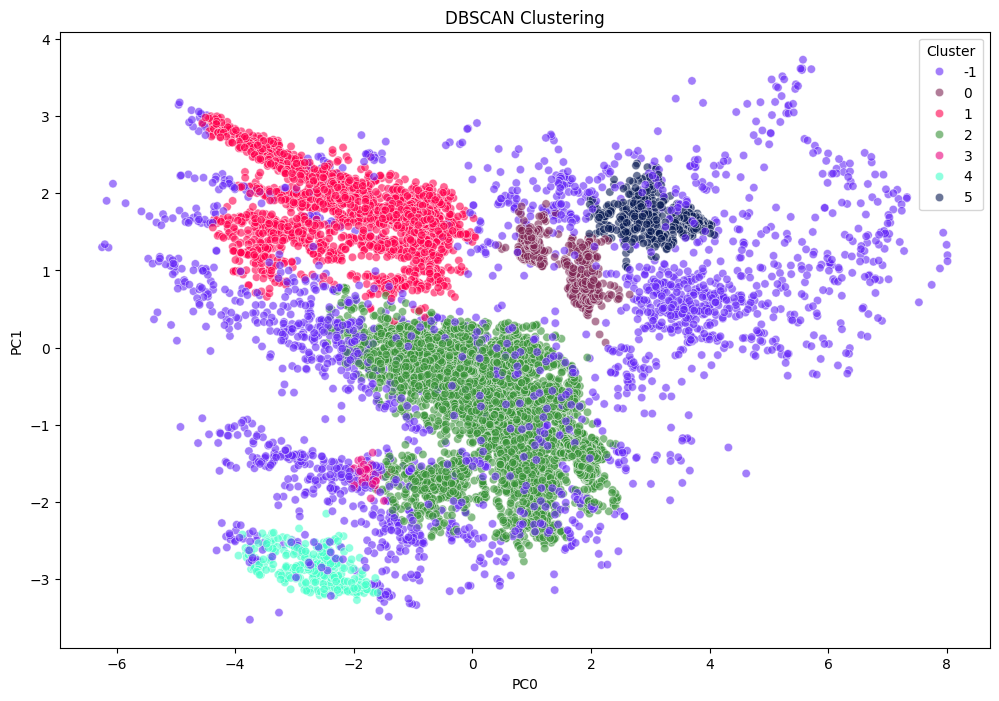

In [ ]:
from sklearn.cluster import DBSCAN

# DBSCAN Clustering
dbscan = DBSCAN(eps=.4, min_samples=50)
pca_df['dbscan_cluster'] = dbscan.fit_predict(X)
palette = ["#6528F7", "#7E2553", "#FF004D", "#379237", "#EA047E", "#45FFCA", "#071952"]

# Plot DBSCAN Clustering
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_df['PC0'], y=pca_df['PC1'], hue=pca_df['dbscan_cluster'], palette=palette, alpha=0.6)
plt.title('DBSCAN Clustering')
plt.xlabel('PC0')
plt.ylabel('PC1')
plt.legend(title='Cluster')
plt.show()

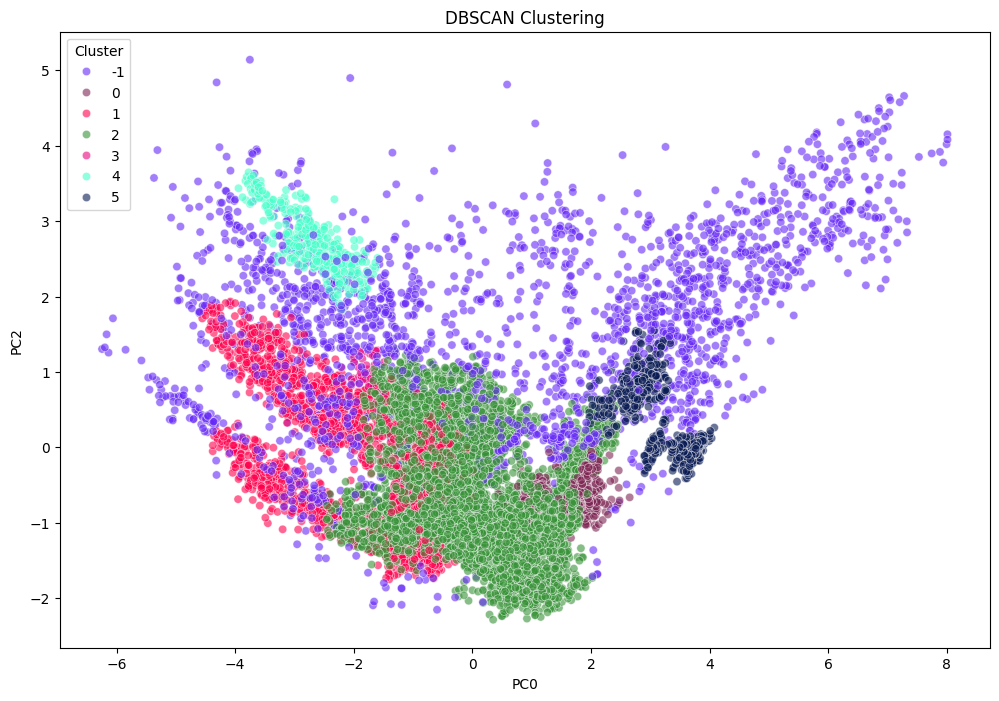

In [104]:
# Plot DBSCAN Clustering
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_df['PC0'], y=pca_df['PC2'], hue=pca_df['dbscan_cluster'], palette=palette, alpha=0.6)
plt.title('DBSCAN Clustering')
plt.xlabel('PC0')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

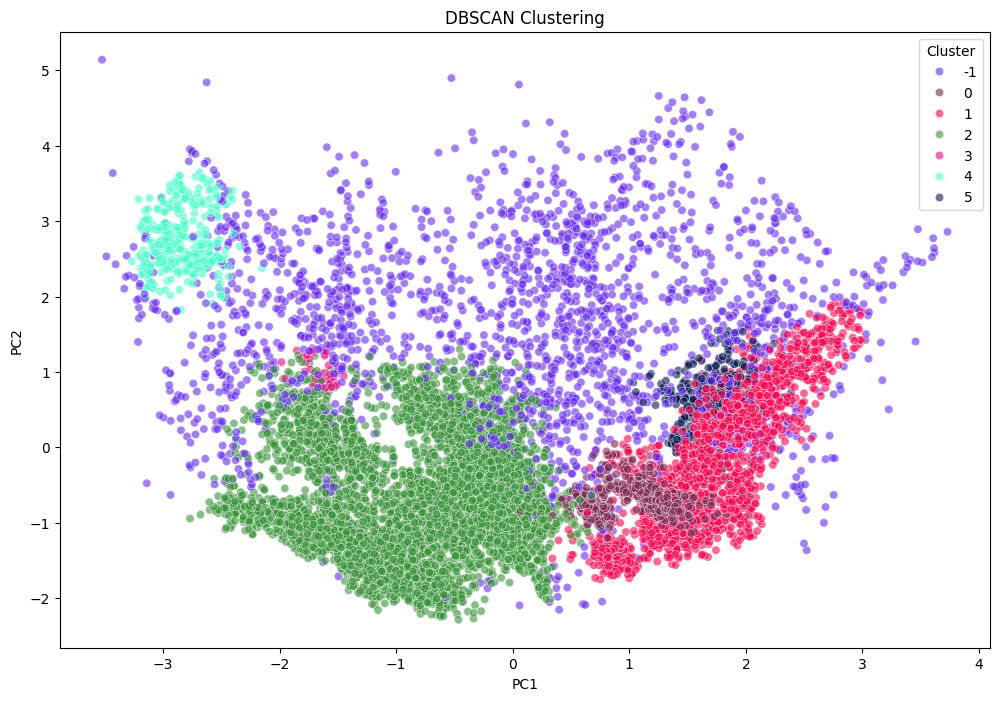

In [105]:
# Plot DBSCAN Clustering
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=pca_df['dbscan_cluster'], palette=palette, alpha=0.6)
plt.title('DBSCAN Clustering')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

In [113]:
palette = ["#6528F7", "#7E2553", "#FF004D", "#379237", "#EA047E", "#45FFCA", "#071952"]

# Plot the PCA results in 3D
fig = px.scatter_3d(
    x=pca_df['PC0'],
    y=pca_df['PC1'],
    z=pca_df['PC2'],
    color=pca_df['dbscan_cluster'].astype(str),
    color_discrete_sequence=palette,
    labels={'x': 'PC0', 'y': 'PC1', 'z': 'PC2', 'color': 'Cluster'},
    # title='3D PCA',
    width=1000,
    height=600
)

fig.update_layout(
    scene=dict(
        xaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black'),
        yaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black'),
        zaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.update_traces(marker=dict(size=3, opacity=0.7))

fig.show()